# DMD model evaluation - Winter 2020

This notebook performs an evaluation of DMD models trained on 10 years (January 2010 to December 2019, with a 6h time step) of atmospheric temperature at 850 hPa (T850) from ERA5, by comparing their reconstruction and forecasting performance as we vary different hyperparameters, namely the number of modes and the type of pre-processing (with and without time-delay embedding, a.k.a. Hankel pre-processing). Reconstructions are evaluated over the last two months of training data (Nov and Dec 2019), while forecasts are evaluated over a 45 day period (Jan and the first half of Feb 2020). Both deterministic and probabilistic (via bootstrap aggregation) DMD models are analyzed. Model performance is compared against short- and long-term climatology. Short-term climatology has been calculated using the same 10 years of training data, whereas long-term climatology corresponds to an average of 1990-2019 data and has been downloaded from the [WeatherBench database](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5-climatology).

## Table of contents

1. Deterministic DMD models
  * 1.1. Grid search of hyperparameters
  * 1.2. RMSE as a function of time
  * 1.3. Anomaly Correlation Coefficient
  * 1.4. Power Spectra
2. Probabilistic DMD models
  * 1.1. Grid search of hyperparameters
  * 1.2. RMSE as a function of time
  * 1.3. Continuous Ranked Probability Score (CRPS)

In [1]:
import pickle
import numpy as np
import xarray as xr
from glob import glob
from pathlib import Path
from matplotlib import pyplot as plt
from dask.distributed import Client
import dask
import pandas as pd
from svdrom.weather_utils import (
    compute_rmse,
    compute_mae,
    expand_time_climatology,
    compute_acc,
    compute_energy_spectrum,
    compute_crps_gaussian,
)

## 1. Deterministic DMD models

### 1.1 Grid search of hyperparameters

The RMSE scores for different DMD fits have been computed with `train.py`, which performs a grid search of DMD hyper-parameters varying the number of modes and the type of pre-processing (with and without Hankel pre-processing).

Here we analyze the deterministic DMD RMSE scores for reconstructions and forecasts, stored in `metrics/deterministic`.

In [2]:
deter_rmse_path = Path("metrics/deterministic")
reconstruction_files = sorted(glob(str(deter_rmse_path) + "/reconstruction*"))
forecast_files = sorted(glob(str(deter_rmse_path) + "/forecast*"))

Create two dictionaries to store the RMSE of the DMD reconstructions: one for reconstructions without Hankel pre-processing and one for reconstructions with Hankel pre-processing. The dictionaries keys correspond to the number of modes in te DMD model, which is taken from the file name. 

In [3]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

Do the same for the RMSE of the DMD forecasts.

In [4]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

The RMSE of the reconstructions and forecasts are already averaged across the spatial dimension (over latitude and longitude). Here we also average them across the temporal dimension to get a single RMSE score per DMD model.

In [5]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

#### Compute climatology RMSE

To have a baseline against which to compare the performance of the DMD models, we now compute the RMSE of climatology forecasts. Two climatologies are used here. Short-term climatology has been computed with `svdrom.weather_utils.compute_climatology()`, using the same training data used to build the DMD models (10 years: 2010-2019). Long-term climatology has been computed using 30 years (1990-2019), and has been downloaded from [WeatherBench](https://weatherbench2.readthedocs.io/en/latest/data-guide.html#era5-climatology).

To compute the RMSE of climatology, we use a local multi-threading Dask cluster.

In [6]:
client = Client(processes=False)

In [8]:
pressure_level = 850
doy_slice = slice(0, 60)  # day-of-year slice

In [9]:
ground_truth_path = Path("input_data/era5_slice.zarr")
clima_long_term_path = Path("input_data/climatology_1990-2019.zarr")
clima_short_term_path = Path("input_data/climatology_2010-2019.zarr")

In [10]:
ground_truth = xr.open_dataarray(ground_truth_path, engine="zarr", chunks="auto")
assert ground_truth.level.values == pressure_level, (
    f"Ground truth data not available at pressure level {pressure_level}."
)

clima_long_term = xr.open_dataarray(clima_long_term_path, engine="zarr", chunks="auto")
clima_long_term = clima_long_term.sel(level=pressure_level)
clima_long_term = clima_long_term.sel(dayofyear=doy_slice)
clima_long_term = expand_time_climatology(clima_long_term, 2020)  # convert doy/hour into time vector

clima_short_term = xr.open_dataarray(clima_short_term_path, engine="zarr", chunks="auto")
assert clima_short_term.level.values == pressure_level, (
    f"Short-term climatology not available at pressure level {pressure_level}."
)
clima_short_term = clima_short_term.sel(dayofyear=doy_slice)
clima_short_term = expand_time_climatology(clima_short_term, 2020)  # convert doy/hour into time vector

In [11]:
keys = list(forecasts.keys())
time = forecasts[keys[0]].time.values

rmse_clima_long_term = compute_rmse(
    ground_truth.sel(time=time),
    clima_long_term.sel(time=time),
).compute()

/Users/dsalvadorjasin/Documents/projects/svdrom-project/grid-search/.venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 712.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [12]:
rmse_clima_short_term = compute_rmse(
    ground_truth.sel(time=time),
    clima_short_term.sel(time=time),
).compute()

/Users/dsalvadorjasin/Documents/projects/svdrom-project/grid-search/.venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 712.92 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Once done computing the RMSE for climatology, we can close the local Dask cluster.

In [13]:
client.close()

#### Plot averaged T850 RMSE scores

Here we plot the RMSE score, averaged across space and time, for each DMD model, as a function of number of modes and type of pre-processing (with and without Hankel pre-processing), and compare against climatology.

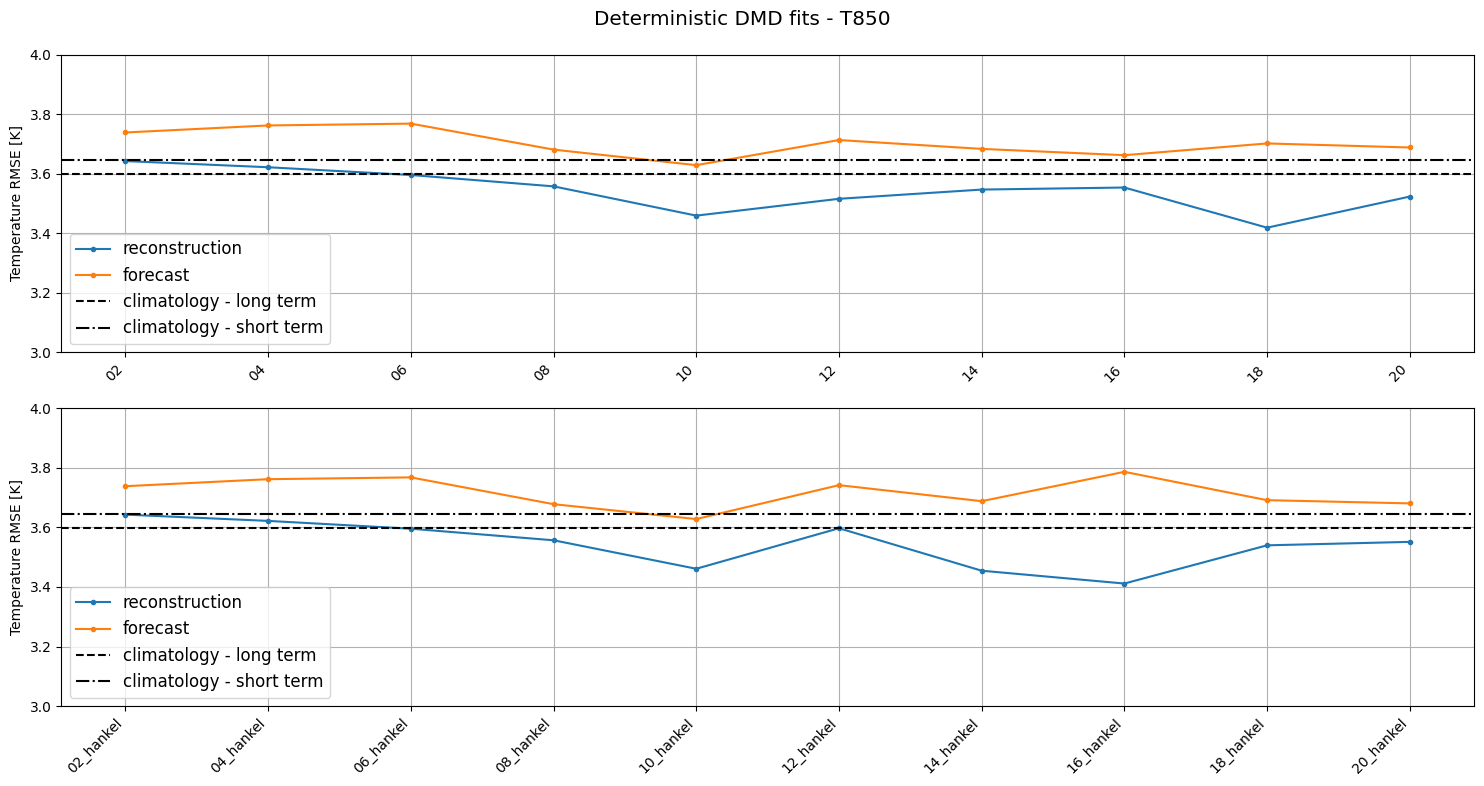

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

def plot_rmse_scores(axs, keys, reconstruction_vals, forecast_vals, ylim = (3, 4)):
    axs.plot(reconstruction_vals, ".-", label="reconstruction")
    axs.plot(forecast_vals, ".-", label="forecast")
    axs.set_xticks(range(len(reconstruction_vals)))
    axs.set_xticklabels(list(keys), rotation=45, ha="right")
    axs.set_ylim(ylim)
    axs.axhline(
        y=rmse_clima_long_term.mean().values,
        color='k',
        linestyle='--',
        label="climatology - long term",
    )
    axs.axhline(
        y=rmse_clima_short_term.mean().values,
        color='k',
        linestyle='-.',
        label="climatology - short term",
    )
    axs.set_ylabel("Temperature RMSE [K]")
    axs.grid()
    axs.legend()

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_rmse_scores(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_rmse_scores(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Deterministic DMD fits - T850")
fig.tight_layout()
plt.show()

The plot above suggests that a DMD model with 10 modes and without Hankel pre-processing might be competitive with climatology. In this case, it seems like Hankel pre-processing is not providing any accuracy improvements.

### 1.2 RMSE as a function of time

Below we plot the RMSE for a reconstruction (over 2 months) and a forecast (over 45 days) for a 20 mode DMD model with Hankel pre-processing, as a function of time, and compare against climatology.

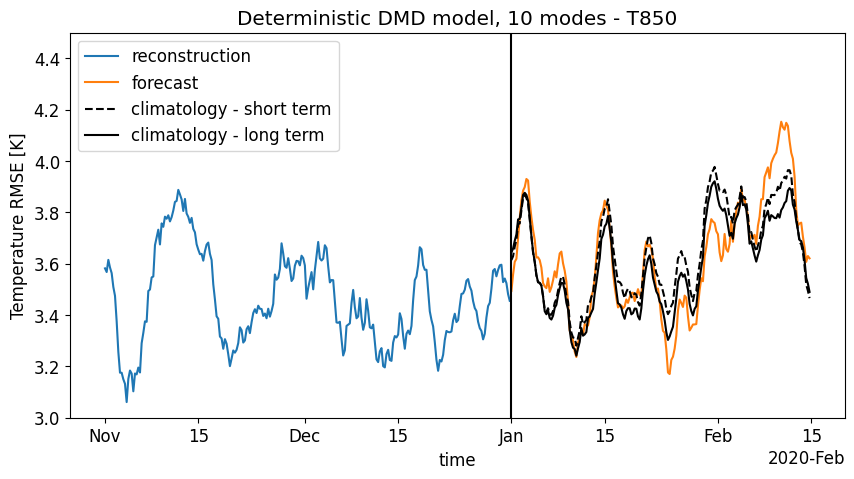

In [16]:
model = "10"
forecast_starts = "2020-01-01T00"

plt.figure(figsize=(10, 5))
reconstructions[model].plot(label="reconstruction")
forecasts[model].plot(label="forecast")
rmse_clima_short_term.plot(color="k", linestyle = "--", label="climatology - short term")
rmse_clima_long_term.plot(color="k", linestyle = "-", label="climatology - long term")
plt.axvline(pd.Timestamp(forecast_starts), color="k")
plt.ylim((3, 4.5))
plt.legend()
plt.ylabel("Temperature RMSE [K]")
plt.title("Deterministic DMD model, 10 modes - T850")

plt.show()

It's clear the RMSE score of the DMD forecast matches climatology almost identically.  

### 1.3 Anomaly Correlation Coefficient

In this section we compute the anomaly correlation coefficient (ACC) of the 45 day DMD forecast as a function of time. We first need to compute the forecast using the fitted DMD model, which we have trained and saved to disk with `train.py`.

In [17]:
# open the fitted 10 mode DMD model without Hankel pre-processing
with open("models/deterministic/dmd_10.pkl", "rb") as f:
    dmd = pickle.load(f)

# open the fitted scaler instance, which contains the time-average,
# as we need to add this to the forecast
with open("input_data/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

We can set up a multi-threaded Dask cluster to compute the forecast.

In [18]:
client = Client(processes=False)

Produce a 45 day forecast and add back the time-average, which was subtracted from the data during pre-processing.

In [19]:
forecast = dmd.forecast("45 D")
forecast = forecast.real.astype("float32")

forecast = forecast.compute()

forecast = forecast.unstack()

forecast = forecast.copy(data=forecast + scaler.mean)

2026-03-28 22:35 - DMD - INFO - Estimated forecast size is 2990131.200 KB.
[dmd.py:1064 -             forecast() ] Estimated forecast size is 2990131.200 KB.
2026-03-28 22:35 - DMD - INFO - Will use Dask to compute the forecast.
[dmd.py:1067 -             forecast() ] Will use Dask to compute the forecast.
2026-03-28 22:35 - DMD - INFO - Computing the DMD forecast...
[dmd.py:1073 -             forecast() ] Computing the DMD forecast...
2026-03-28 22:35 - DMD - INFO - Done.
[dmd.py:1080 -             forecast() ] Done.
/Users/dsalvadorjasin/Documents/projects/svdrom-project/grid-search/.venv/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 166.40 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Now we have the 45 day forecast, we can compute the ACC.

In [20]:
acc = compute_acc(
    ground_truth=ground_truth.sel(time=forecast.time),
    prediction=forecast.reindex(latitude=ground_truth.latitude),
    climatology=clima_long_term.sel(time=forecast.time)
)

In [21]:
client.close()

Plot the ACC as a function of time.

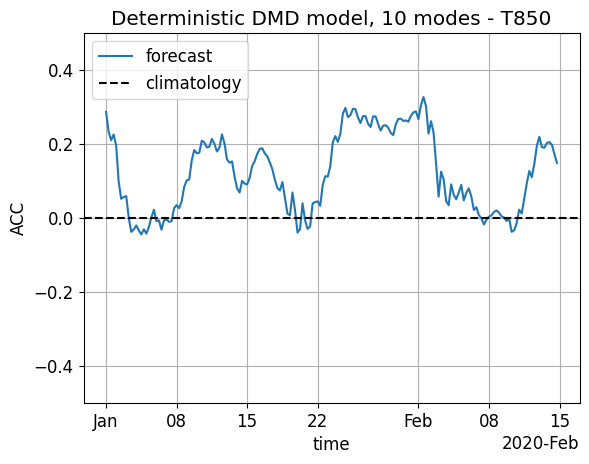

In [22]:
plt.figure()
acc.plot(label="forecast")
plt.ylim((-0.5, 0.5))
plt.axhline(y=0, color="k", linestyle="--", label="climatology")
plt.grid()
plt.ylabel("ACC")
plt.title("Deterministic DMD model, 10 modes - T850")
plt.legend()
plt.show()

In [23]:
print(f"Average ACC: {acc.mean().values:.2f}")

Average ACC: 0.12


While the ACC is low, it remains positive during most of the forecast period, and averages to 0.11. There is a clear bias towards a positive ACC. Since ACC is zero for climatology, this plot shows that a 10 mode DMD model is not just reproducing climatology - it's capturing additional variability. 

### 1.4 Power spectra

In this section we compute the power spectra for the ground truth, climatology and the DMD forecast.

In [24]:
ground_truth_spectrum = compute_energy_spectrum(ground_truth.sel(time=forecast.time).compute())
forecast_spectrum = compute_energy_spectrum(forecast.compute())
clima_spectrum = compute_energy_spectrum(clima_long_term.sel(time=forecast.time).compute())

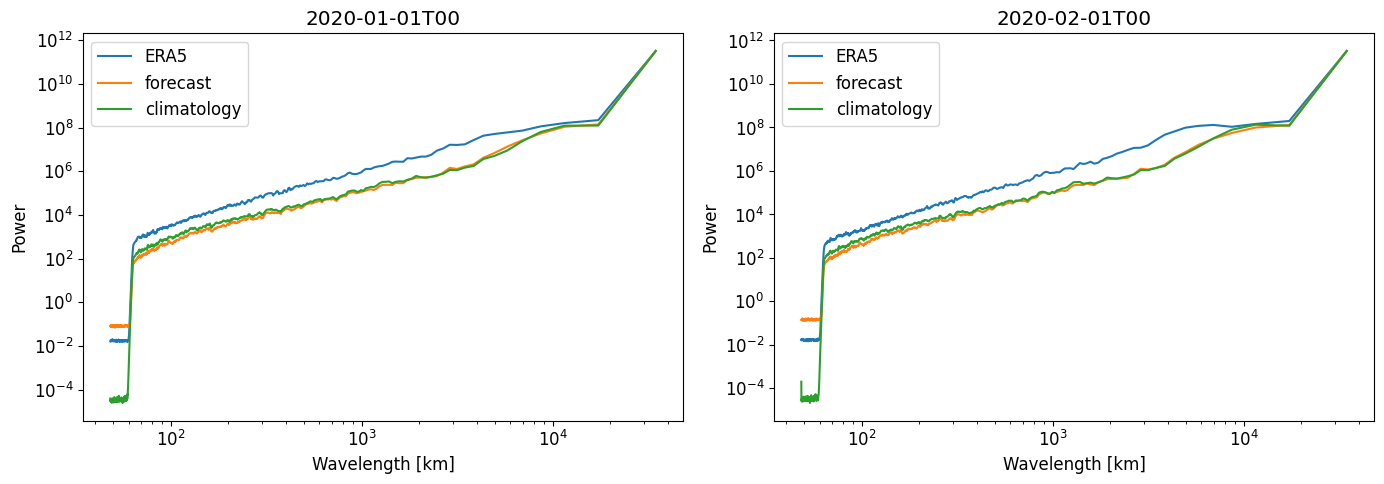

In [25]:
def plot_power_spectra(timestamp1, timestamp2):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    for ax, timestamp in zip(axs, [timestamp1, timestamp2]):
        ax.loglog(
            ground_truth_spectrum.wavelength / 1000,
            ground_truth_spectrum.sel(time=timestamp).data,
            label="ERA5"
        )
        ax.loglog(
            forecast_spectrum.wavelength / 1000,
            forecast_spectrum.sel(time=timestamp).data,
            label="forecast"
        )
        ax.loglog(
            clima_spectrum.wavelength / 1000,
            clima_spectrum.sel(time=timestamp).data,
            label="climatology"
        )
        ax.set_ylabel("Power")
        ax.set_xlabel("Wavelength [km]")
        ax.set_title(timestamp)
        ax.legend()
    fig.tight_layout()
    plt.show()

plot_power_spectra("2020-01-01T00", "2020-02-01T00")


The forecast spectra are very close to climatology, indicating DMD is extracting the large-scale, low-frequency variability that climatology captures. The spectra don't blow up at long lead lead times, indicating the DMD forecast remains stable.

## 2. Probabilistic DMD models

### 2.1 Grid search of hyperparameters

We now repeat the same process for the probabilistic DMD models, which have been obtained from ensembles of DMD fits produced using bootstrap aggregation. We only use the mean and variance of the ensemble of predictions here. The RMSE error is computed from the ensemble mean. 

In [26]:
proba_rmse_path = Path("metrics/probabilistic")
reconstruction_files = sorted(glob(str(proba_rmse_path) + "/reconstruction*"))
forecast_files = sorted(glob(str(proba_rmse_path) + "/forecast*"))

In [27]:
reconstructions = {}
reconstructions_hankel = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        reconstructions_hankel[name] = xr.open_dataarray(file)
    else:
        reconstructions[name] = xr.open_dataarray(file)

In [28]:
forecasts = {}
forecasts_hankel = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    if "hankel" in name:
        forecasts_hankel[name] = xr.open_dataarray(file)
    else:
        forecasts[name] = xr.open_dataarray(file)

In [29]:
reconstruction_averages = []
reconstruction_hankel_averages = []
forecast_averages = []
forecast_hankel_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

for key in reconstructions_hankel.keys():
    reconstruction_hankel_averages.append(
        (key, reconstructions_hankel[key].mean().values)
    )
    forecast_hankel_averages.append((key, forecasts_hankel[key].mean().values))

#### Plot averaged T850 RMSE scores

As we did for the deterministic DMD model, below we plot the RMSE error for the ensemble mean and compare against climatology, for DMD models with different number of modes and type of pre-processing (with and without time-delay embedding/Hankel).

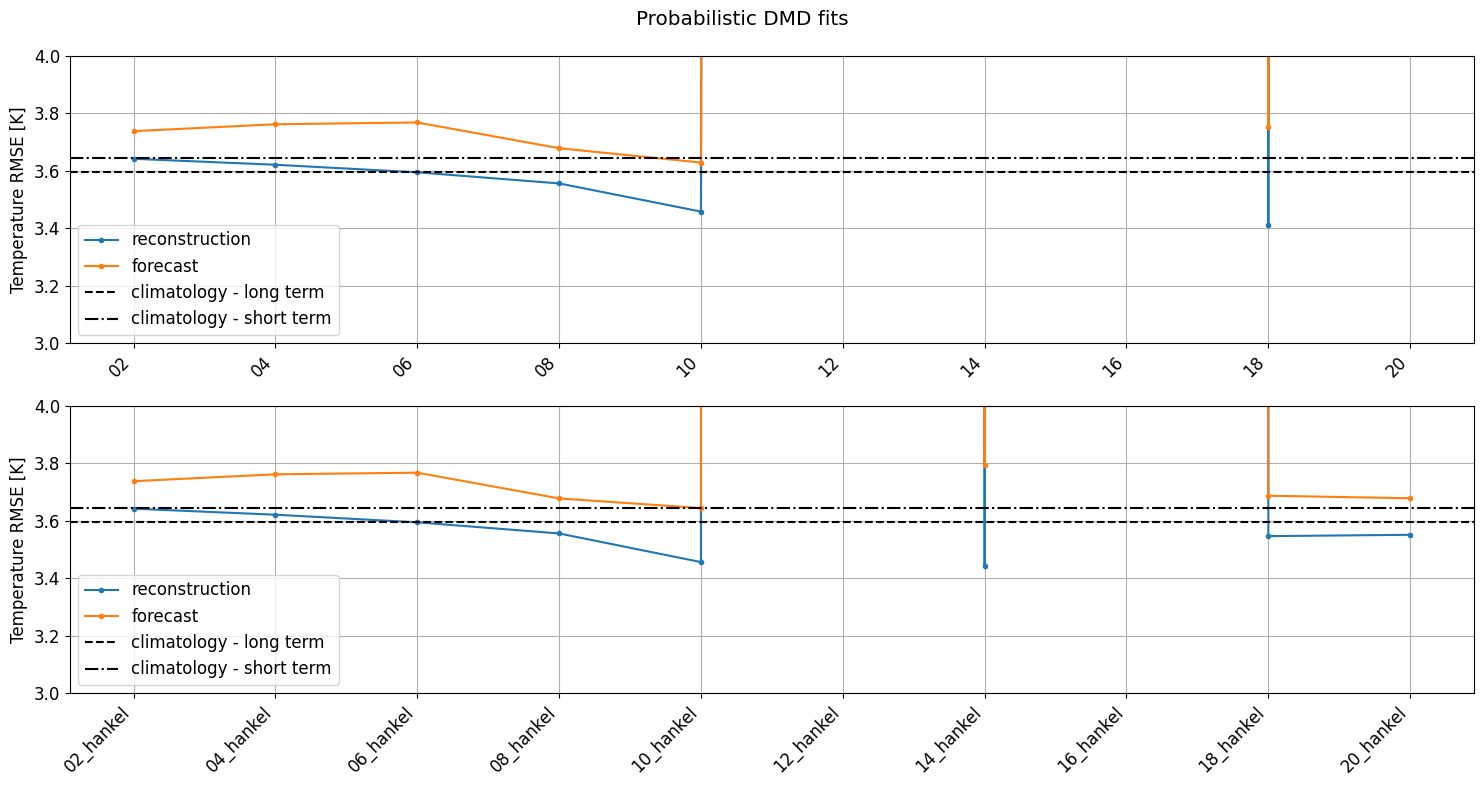

In [30]:
fig, axs = plt.subplots(2, 1, figsize=(15, 8))
axs = axs.flatten()
plt.rcParams.update({'font.size': 12})

keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plot_rmse_scores(axs[0], keys, reconstruction_vals, forecast_vals)

keys = [key for key, _ in reconstruction_hankel_averages]
reconstruction_vals = [val for _, val in reconstruction_hankel_averages]
forecast_vals = [val for _, val in forecast_hankel_averages]
plot_rmse_scores(axs[1], keys, reconstruction_vals, forecast_vals)

fig.suptitle("Probabilistic DMD fits")
fig.tight_layout()
plt.show()

From the plot above, it's clear some DMD fits are unstable. This is because some of the ensemble members in those cases are spurious, leading to a spurious ensemble average. Bootstrap aggregation is performed by randomly sampling snapshots from the data matrix while maintaining time order, and it might be that some of the resulting matrices become ill-conditioned.

As we saw in the deterministic DMD case, a model with 10 modes and without Hankel pre-processing seems to be competitive with climatology.

### 2.2 RMSE as a function of time

Below we plot the reconstruction and forecast RMSE for a probabilistic DMD model with 20 modes and Hankel pre-processing, and compare against climatology.

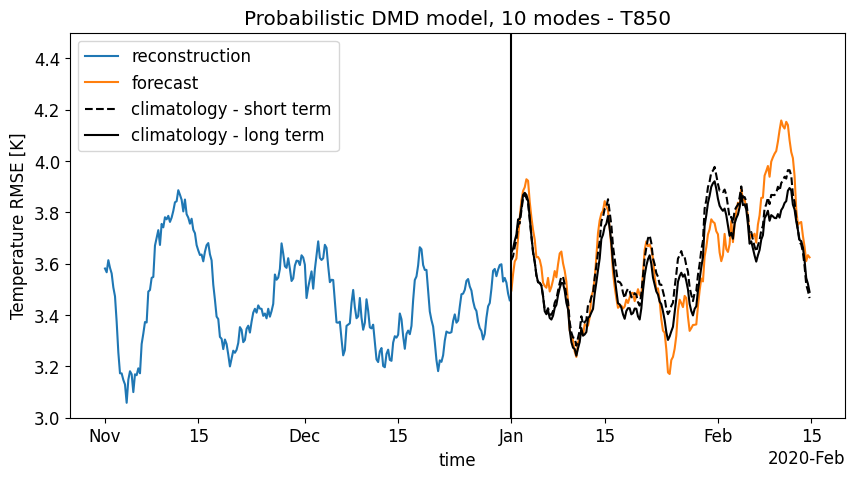

In [43]:
model = "10"
forecast_starts = "2020-01-01T00"

plt.figure(figsize=(10, 5))
reconstructions[model].plot(label="reconstruction")
forecasts[model].plot(label="forecast")
rmse_clima_short_term.plot(color="k", linestyle = "--", label="climatology - short term")
rmse_clima_long_term.plot(color="k", linestyle = "-", label="climatology - long term")
plt.axvline(pd.Timestamp(forecast_starts), color="k")
plt.ylim((3, 4.5))
plt.legend()
plt.ylabel("Temperature RMSE [K]")
plt.title("Probabilistic DMD model, 10 modes - T850")

plt.show()

As shown, the behavior of the probabilistic DMD fit is very similar to the deterministic DMD model.

### 2.3 Continuous Ranked Probability Score (CRPS)

Since we are dealing with a probabilistic DMD model producing the mean and variance of an ensemble of predictions, we can compute the CRPS of the forecast assuming a Gaussian distribution.

We don't have the forecast saved on disk, but we do have the fitted DMD model, so we can quickly compute the forecast now.

In [34]:
# open the fitted DMD model
with open("models/probabilistic/dmd_10.pkl", "rb") as f:
    dmd = pickle.load(f)

In [ ]:
# start a multi-threaded Dask cluster
client = Client(processes=False)

In [ ]:
# now produce a probabilistic 45 day forecast
forecast_mean, forecast_var = dmd.forecast("45 D")

forecast_mean, forecast_var = dask.compute(
    forecast_mean.real.astype("float32"),
    forecast_var.astype("float32"),
)

Since we have fitted the DMD model on the fluctuations about the time-average, we now need to add back the time-average to the ensemble mean.

In [ ]:
forecast_mean = forecast_mean.unstack()
forecast_var = forecast_var.unstack()

In [ ]:
# open the fitted scale instance, which contains the time average
with open("input_data/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [ ]:
forecast_mean = forecast_mean.copy(data=forecast_mean + scaler.mean)

In [ ]:
# save the forecasts to disk

path = Path("forecasts/probabilistic")
path.mkdir(parents=True, exist_ok=True)

file_name = "forecast_mean_20_hankel.nc"
forecast_mean.to_netcdf(path / file_name)

file_name = "forecast_var_20_hankel.nc"
forecast_var.to_netcdf(path / file_name)

Now we have the mean and variance of the forecast, we can compute the CRPS assuming a Gaussian distribution. We will compare the CRPS of the DMD forecast against the CRPS of a probabilistic climatology, where the mean and standard deviation have been computed by treating each of the years between 2010 and 2019 as an ensemble member.

In [35]:
ground_truth = xr.open_dataarray("input_data/era5_slice.zarr", engine="zarr")
forecast_mean = xr.open_dataarray("forecasts/probabilistic/forecast_mean_10.nc")
forecast_var = xr.open_dataarray("forecasts/probabilistic/forecast_var_10.nc")
clima_mean = xr.open_dataarray("input_data/climatology_2010-2019.zarr", chunks="auto", engine="zarr")
clima_std = xr.open_dataarray("input_data/climatology_std_2010-2019.zarr", chunks="auto", engine="zarr")

doy_slice = slice(0, 60)
clima_mean = clima_mean.sel(dayofyear=doy_slice)
clima_std = clima_std.sel(dayofyear=doy_slice)

clima_mean = expand_time_climatology(clima_mean, year=2020)
clima_std = expand_time_climatology(clima_std, year=2020)

Compute the CRPS for the probabilistic DMD forecast.

In [36]:
crps = compute_crps_gaussian(
    ground_truth=ground_truth.sel(time=forecast_mean.time).reindex(latitude=forecast_mean.latitude),
    prediction_mean=forecast_mean,
    prediction_std=np.sqrt(forecast_var)
)

Compute the CRPS for a probabilistic climatology.

In [37]:
crps_clima = compute_crps_gaussian(
    ground_truth=ground_truth.sel(time=forecast_mean.time).reindex(latitude=clima_mean.latitude),
    prediction_mean=clima_mean.sel(time=forecast_mean.time),
    prediction_std=clima_std.sel(time=forecast_mean.time),
)

In [ ]:
# close the Dask cluster now we are done with it
client.close()

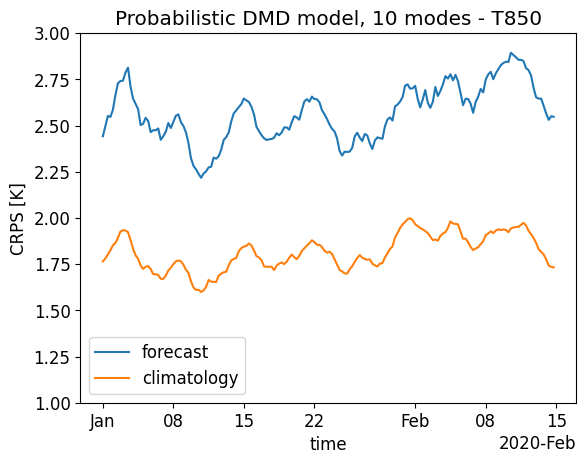

In [44]:
plt.figure()

crps.plot(label="forecast")
crps_clima.plot(label="climatology")

plt.legend()
plt.ylabel("CRPS [K]")
plt.ylim((1, 3))
plt.title("Probabilistic DMD model, 10 modes - T850")
plt.show()

Probabilistic climatology has a much better CRPS than the probabilistic DMD forecast. The main reason for this is that bootstrap aggregation (bagging), which is used to produce the ensemble of DMD forecasts, is not generating epistemic uncertainty. Even though 20% of the snapshots are dropped in each of the trials, the resulting ensemble spread is too small. This is severely penalized by CRPS. The mean forecast, however, is still accurate and in par with climatology. This can be concluded by plotting the mean absolute error (MAE), which is a special case of CRPS when the forecast distribution collapses to a delta function.

In [39]:
mae = compute_mae(
    ground_truth=ground_truth.sel(time=forecast_mean.time).reindex(latitude=forecast_mean.latitude),
    prediction=forecast_mean,
)

mae_clima = compute_mae(
    ground_truth=ground_truth.sel(time=forecast_mean.time).reindex(latitude=clima_mean.latitude),
    prediction=clima_mean.sel(time=forecast_mean.time),
)

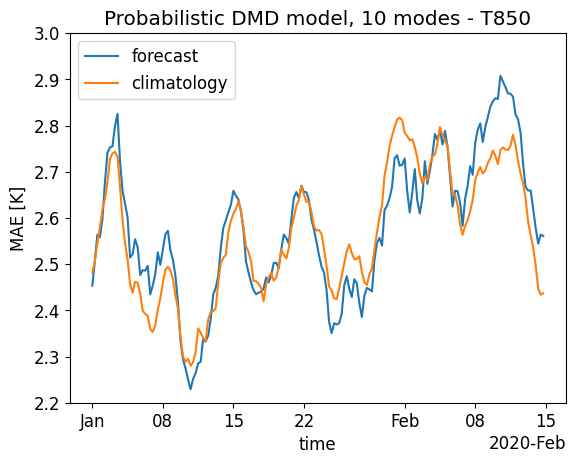

In [45]:
plt.figure()

mae.plot(label="forecast")
mae_clima.plot(label="climatology")

plt.legend()
plt.ylabel("MAE [K]")
plt.ylim((2.2, 3))
plt.title("Probabilistic DMD model, 10 modes - T850")
plt.show()

Bagging optimized DMD produces an underdispersed probabilistic forecast in this case. However, this exercise has proven that even with missing/subsampled data (in this case, 20% of the snapshots are dropped in each bagging trial), DMD can still accurately capture the large-scale dynamics and the forecasts remain stable.